In [1]:
import osmnx as ox
import networkx as nx

ox.settings.use_cache = True

center_point = (44.965, -93.18)   # approximate center of Minneapolis-St Paul
radius_m = 20000                  # 20 km radius (taking a sample of this Metro Area

#Query for motorways and motorway links
motorway_filter = '["highway"~"motorway|motorway_link"]'

#Initialize graph
G = ox.graph_from_point(
    center_point,
    dist=radius_m,
    custom_filter=motorway_filter,
    simplify=False,
    retain_all=True
)


In [2]:
G = ox.routing.add_edge_speeds(G)
G = ox.routing.add_edge_travel_times(G)


In [3]:
D = ox.convert.to_digraph(G, weight="travel_time")

#calculate betweenness centrality
bc = nx.betweenness_centrality(
    D,
    k=300,                     # sample 300 nodes instead of full exact BC, to ease computation time
    weight="travel_time",
    normalized=True
)

nx.set_node_attributes(G, bc, "bc")


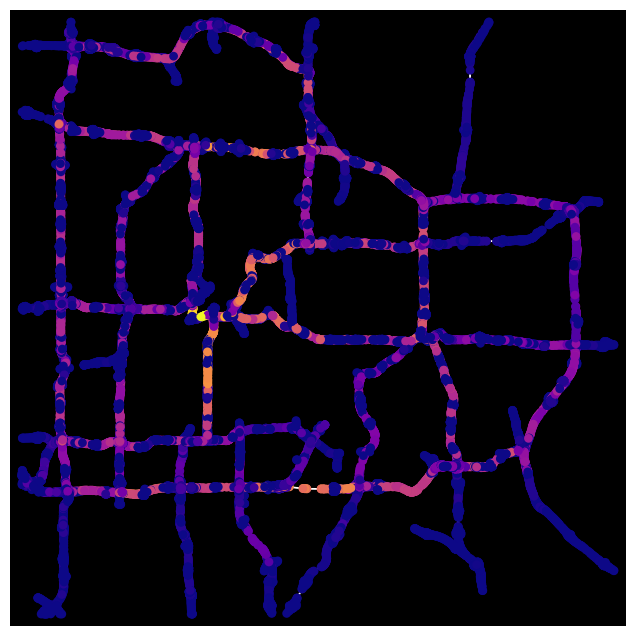

In [4]:
#load graph of points based on betweenness centrality
nc = ox.plot.get_node_colors_by_attr(G, "bc", cmap="plasma")
fig, ax = ox.plot_graph(
    G,
    bgcolor="black",
    node_color=nc,
    node_size=40,
    edge_color="white",
    edge_linewidth=1
)


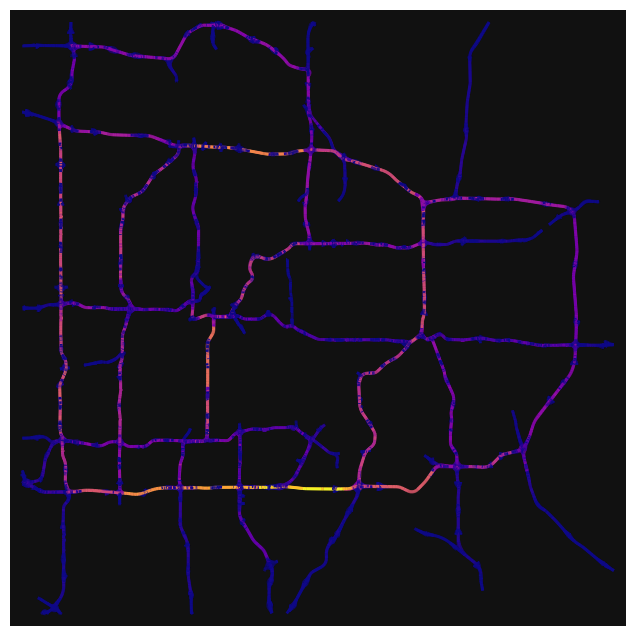

In [9]:
#convert this graph to edge centrality
edge_centrality = nx.betweenness_centrality(nx.line_graph(G), k=500)
nx.set_edge_attributes(G, edge_centrality, "edge_centrality")

ec = ox.plot.get_edge_colors_by_attr(G, 'edge_centrality', cmap='plasma')
fig, ax = ox.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)

In [13]:
#download edges and nodes files
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
gdf_edges.to_file("/Users/sleibowitz/Downloads/edges1.geojson", driver="GeoJSON")
gdf_nodes.to_file("/Users/sleibowitz/Downloads/nodes1.geojson", driver="GeoJSON")


In [64]:
import geopandas as gpd

#Load in files containing VMT, Proximity to EV chargers, and betweenness centrality
g1 = gpd.read_file("/Users/sleibowitz/Downloads/edges1.geojson")          #Twin Cities OSMnx edges
g2 = gpd.read_file("/Users/sleibowitz/Downloads/interstates_with_charger_info.geojson")  # National dataset

In [65]:
#Reproject g2
g2 = g2.to_crs(epsg=4326)

In [66]:
#Condense g2 to only include interstate highways in Minnesota

import osmnx as ox

minnesota = ox.geocode_to_gdf("Minnesota")

In [67]:
#Merge g2 with minn_union
minn_union = minnesota.union_all()
g2_minn = g2[g2.intersects(minn_union)]

In [68]:
#Simplify geometry
g1.loc[:, "geom_simple"] = g1.geometry.simplify(0.00001)
g2_minn = g2_minn.copy()  
g2_minn.loc[:, "geom_simple"] = g2_minn.geometry.simplify(0.00001)

In [69]:
#Reproject both datasets to a projected CRS
g1_proj = g1.to_crs(3071)
g2_minn_proj = g2_minn.to_crs(3071)

In [70]:
#Simplify geometry for faster computation time & visualization
g1_proj["geom_simple"] = g1_proj.geometry.simplify(5)        #(5 meters)
g2_minn_proj["geom_simple"] = g2_minn_proj.geometry.simplify(5)

#Merge datasets
merged_proj = gpd.sjoin_nearest(
    g1_proj.set_geometry("geom_simple"),
    g2_minn_proj.set_geometry("geom_simple"),
    how="left",
    distance_col="match_distance"
)


In [71]:
#Correct projected coordinate system
merged = merged_proj.to_crs(4326)

In [72]:
#Ensure there is one correct geometry field
merged = merged.drop(columns=["geom_simple", "geometry_right"], errors="ignore")


In [73]:
[col for col in merged.columns if merged[col].dtype == "geometry"]

['geometry_left']

In [74]:
merged.head()


,u,v,key,osmid,highway,oneway,reversed,length,speed_kph,travel_time,...,index_right,:id,aadt,sectionlength,vmt,index_charger,dist_to_charger,charger_count_within_50_miles,dist_charger_miles,match_distance
0,33295645,476751792,0,39770747,motorway_link,True,False,19.423498,78.156445,0.894675,...,402357,row-6haw_sqz8_twyp,137310.0,0.082,11259.42,11042,4039.937523,27.0,2.510301,3151.653569
1,33296475,33296540,0,6022337,motorway,True,False,29.300703,96.560400,1.092399,...,399732,row-9h9u~8fd5-eap6,64107.0,27.7696,1780225.7472,4773,82.418489,54.0,0.051212,3329.790180
2,33296540,486973275,0,6022337,motorway,True,False,220.055464,96.560400,8.204188,...,399732,row-9h9u~8fd5-eap6,64107.0,27.7696,1780225.7472,4773,82.418489,54.0,0.051212,3331.210973
3,33296632,247963887,0,1000813543,motorway,True,False,103.911274,104.607100,3.576054,...,399732,row-9h9u~8fd5-eap6,64107.0,27.7696,1780225.7472,4773,82.418489,54.0,0.051212,1781.273746
4,33296692,247963908,0,6030212,motorway_link,True,False,30.254982,78.156445,1.393589,...,399732,row-9h9u~8fd5-eap6,64107.0,27.7696,1780225.7472,4773,82.418489,54.0,0.051212,2290.811457


In [75]:
#Ensure geometry is set to the correct geometry column
merged = merged.set_geometry("geometry_left")

In [76]:
#Download GeoJSON of merged datasets 
merged.to_file("/Users/sleibowitz/Downloads/twincities_interstates_merged.geojson", driver="GeoJSON")

In [77]:
import geopandas as gpd
import pandas as pd

merged_final = gpd.read_file("/Users/sleibowitz/Downloads/twincities_interstates_merged.geojson")

In [78]:
merged_final.columns

Index(['u', 'v', 'key', 'osmid', 'highway', 'oneway', 'reversed', 'length',
       'speed_kph', 'travel_time', 'edge_centrality', 'lanes', 'maxspeed',
       'name', 'ref', 'bridge', 'access', 'tunnel', 'junction', 'width',
       'index_right', ':id', 'aadt', 'sectionlength', 'vmt', 'index_charger',
       'dist_to_charger', 'charger_count_within_50_miles',
       'dist_charger_miles', 'match_distance', 'geometry'],
      dtype='object')

In [79]:
merged_final.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 51924 entries, 0 to 51923
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   u                              51924 non-null  int64   
 1   v                              51924 non-null  int64   
 2   key                            51924 non-null  int32   
 3   osmid                          51924 non-null  int32   
 4   highway                        51924 non-null  object  
 5   oneway                         51924 non-null  bool    
 6   reversed                       51924 non-null  bool    
 7   length                         51924 non-null  float64 
 8   speed_kph                      51924 non-null  float64 
 9   travel_time                    51924 non-null  float64 
 10  edge_centrality                51924 non-null  float64 
 11  lanes                          36520 non-null  object  
 12  maxspeed                

In [80]:
#Change vmt to type float64
merged_final["vmt"] = pd.to_numeric(merged_final["vmt"], errors="coerce")

In [81]:
#Calculate final combined metric for new EV charging location proposal
merged_final["combined_metric"]=(
    merged_final["edge_centrality"] *
    merged_final["vmt"] *
    merged_final["dist_charger_miles"]
)

In [88]:
pip install contextily

Note: you may need to restart the kernel to use updated packages.


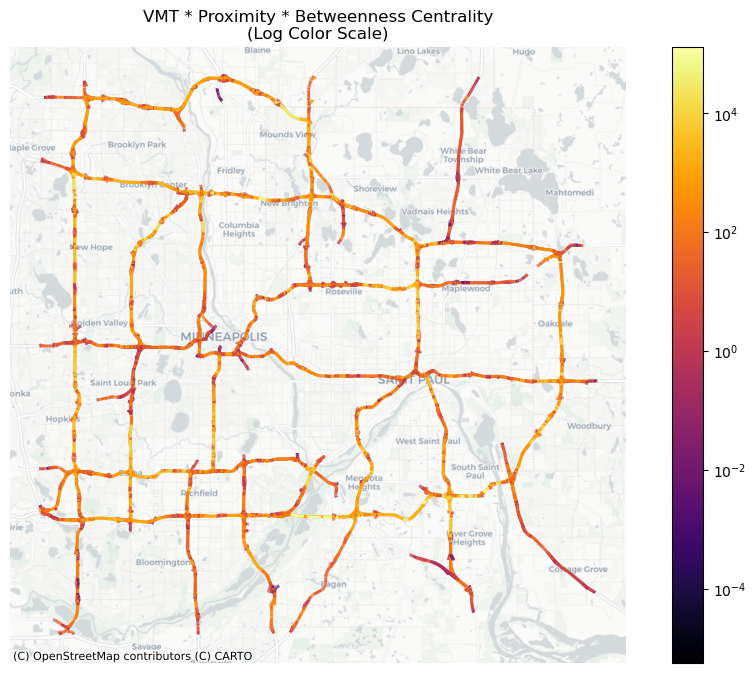

In [119]:
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.colors import LogNorm

#overall plot of highways in Twin Cities area, visualized by the combined metric
#Higher values = 
    #higher VMT (more thru-traffic), 
    #higher distance to EV charging locations (farther from chargers),
    #and higher betweenness (more people rely on these routes)


# Reproject to Web Mercator
merged_webmerc = merged_final.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 8))

merged_webmerc.plot(
    column="combined_metric",
    cmap="inferno",
    linewidth=2,
    norm=LogNorm(),
    legend=True,
    ax=ax
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=11
)

ax.set_title("VMT * Proximity * Betweenness Centrality\n(Log Color Scale)")
ax.axis("off")
plt.show()




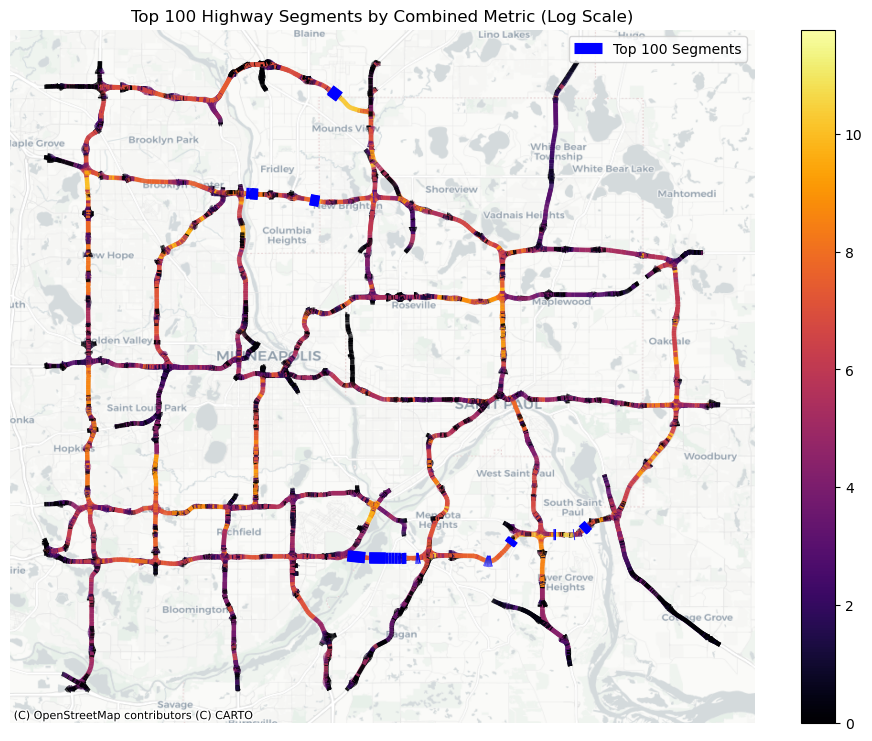

In [111]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# Reproject
g = merged_final.to_crs(3857)

# Compute log metric
g["combined_log"] = np.log1p(g["combined_metric"])

# Extract top 100 locations and reproject them
top10 = merged_final.sort_values("combined_metric", ascending=False).head(100)
top10 = top10.to_crs(3857)

# Create plot
fig, ax = plt.subplots(figsize=(12, 9))

g.plot(
    ax=ax,
    column="combined_log",
    cmap="inferno",
    linewidth=3,
    legend=True,
    alpha=0.9,
    aspect=None
)

top10.plot(
    ax=ax,
    color="blue",
    linewidth=8,
    alpha=1.0,
    label="Top 100 Segments",
    aspect=None
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    zoom=11
)

ax.set_axis_off()
plt.title("Top 100 Highway Segments by Combined Metric (Log Scale)")
plt.legend()
plt.show()


In [115]:
#Top locations needing new EV chargers based on VMT, distance to other EV charging locations, and betweenness centrality:
#1) I-494 around Fort Snelling State Park and MSP Airport
#2) I-494 near Sunfish Lake
#3) Highway 10 near Blaine
#4) I-694 near Fridley
#5) I-494 in South St. Paul


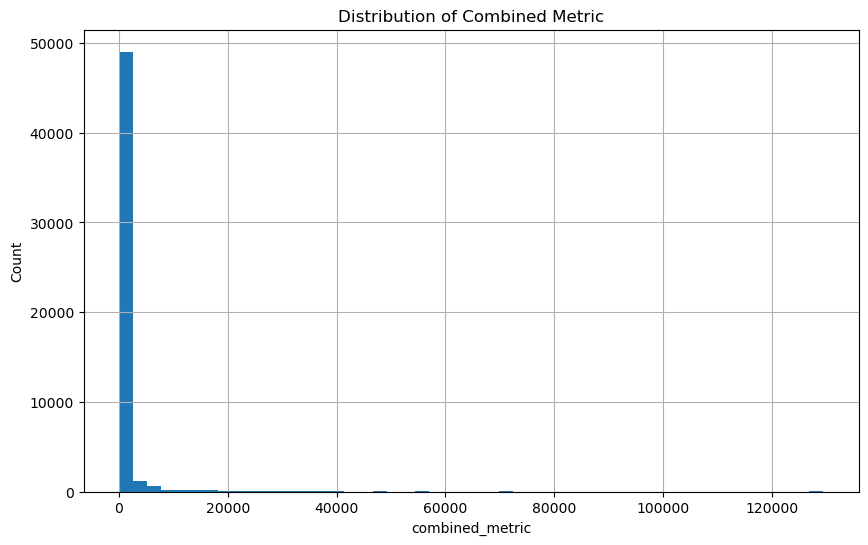

In [84]:
import matplotlib.pyplot as plt

merged_final["combined_metric"].hist(bins=50, figsize=(10,6))
plt.title("Distribution of Combined Metric")
plt.xlabel("combined_metric")
plt.ylabel("Count")
plt.show()

#highly skewed distribution of VMT*distance*betweenness

In [99]:
merged_final["sectionlength"].min(), merged_final["sectionlength"].max()
#Sections of highway range from 0.0003 miles (about 1.5 ft) to 9.65 miles.

('0.0003', '9.6539')

In [112]:
merged_final["vmt"].min(), merged_final["vmt"].max()

(25.447, 1780225.7472)

In [113]:
merged_final["dist_charger_miles"].min(), merged_final["dist_charger_miles"].max()

(0.03512588533810578, 6.8861090597516315)

In [114]:
merged_final["edge_centrality"].min(), merged_final["edge_centrality"].max()

(0.0, 0.07403498479093298)

In [ ]:
#Since values for all of these metrics are 0 or positive, and 
#high values are more desirable for each field,
#the overall suitability score can be calculated by simply
#multiplying these three values together.
#for further exploration, we could weight them differently
#and examine how the resulting highest scores vary.